## Data loading

In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [15]:
# Load dataset
ds_train = tfds.load("stl10", split="train", as_supervised=False)
ds_test  = tfds.load("stl10", split="test",  as_supervised=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.HTV85Z_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.HTV85Z_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [16]:
def preprocess(sample):
    img = tf.cast(sample["image"], tf.float32) / 255.0  # [0 to 1] tho fir sigmod use hoga
    gray = tf.image.rgb_to_grayscale(img)
    return gray, img

In [17]:
BATCH_SIZE = 32

train_ds = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


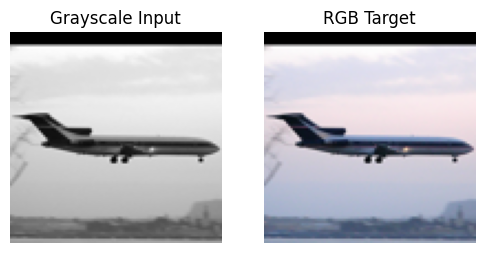

In [29]:
for gray, rgb in test_ds.take(1):
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Grayscale Input")
    plt.imshow(gray[-15].numpy(), cmap="gray") # .squeeze()
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("RGB Target")
    plt.imshow(rgb[-15].numpy())
    plt.axis("off")

    plt.show()




---


## Auto Encoder making 🤷‍♂️


---



### Encoder

In [31]:
from tensorflow.keras import layers, models

encoder = models.Sequential([
    layers.Input(shape=(96, 96, 1)),

    layers.Conv2D(64,  kernel_size=3, strides=2, padding="same", activation="relu"),  # 48x48
    layers.Conv2D(128, kernel_size=3, strides=2, padding="same", activation="relu"),  # 24x24
    layers.Conv2D(256, kernel_size=3, strides=2, padding="same", activation="relu"),  # 12x12
    layers.Conv2D(256, kernel_size=3, strides=2, padding="same", activation="relu"),  # 6x6

])
encoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 959,744 (3.66 MB)

 Trainable params: 959,744 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

# 6 × 6 × 256   ← LR (latent representation) 😁

### Decoder

In [32]:
decoder = models.Sequential([
    layers.Input(shape=(6, 6, 256)),

    layers.Conv2DTranspose(256, 3, strides=2, padding="same", activation="relu"),  # 12x12
    layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu"),  # 24x24
    layers.Conv2DTranspose(64,  3, strides=2, padding="same", activation="relu"),  # 48x48
    layers.Conv2DTranspose(3,   3, strides=2, padding="same", activation="sigmoid") # 96x96x3
])
decoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 12, 12, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 24, 24, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 96, 96, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 960,643 (3.66 MB)

 Trainable params: 960,643 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

# Decoder (960,643) and Encoder (959,744) so total para is 1.9 Million params

In [36]:
autoencoder = models.Sequential([encoder,decoder])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 6, 6, 256)      │       959,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 96, 96, 3)      │       960,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,387 (7.33 MB)

 Trainable params: 1,920,387 (7.33 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Input
inp = layers.Input(shape=(96, 96, 1))

# Encoder
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(inp)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
latent = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
# latent = (6,6,256)

# Decoder
x = layers.Conv2DTranspose(256, 3, strides=2, padding="same", activation="relu")(latent)
x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(64,  3, strides=2, padding="same", activation="relu")(x)
out = layers.Conv2DTranspose(3,  3, strides=2, padding="same", activation="sigmoid")(x)

# Autoencoder
gpt_vala_model = models.Model(inp, out)
gpt_vala_model.compile(optimizer="adam", loss="mse")

gpt_vala_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 12, 12, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 24, 24, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 96, 96, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,387 (7.33 MB)

 Trainable params: 1,920,387 (7.33 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
gpt_vala_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

# My model

In [39]:
EPOCHS = 50

history = autoencoder.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 0.0523 - val_loss: 0.0169
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0159 - val_loss: 0.0138
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 0.0132 - val_loss: 0.0123
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - loss: 0.0120 - val_loss: 0.0122
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0107 - val_loss: 0.0105
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0103 - val_loss: 0.0100
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0096 - val_loss: 0.0096
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0096 - val_loss: 0.0094
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 12/50
157/157 ━━━━━━━━━━━

GPT ka Model

In [59]:
EPOCHS = 50

history = gpt_vala_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.0506 - val_loss: 0.0177
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0162 - val_loss: 0.0135
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0133 - val_loss: 0.0131
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0118 - val_loss: 0.0109
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0109 - val_loss: 0.0114
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0099 - val_loss: 0.0119
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.0098 - val_loss: 0.0094
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 12/50
157/157 ━━━━━━━━━━━━━

# Testing of model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


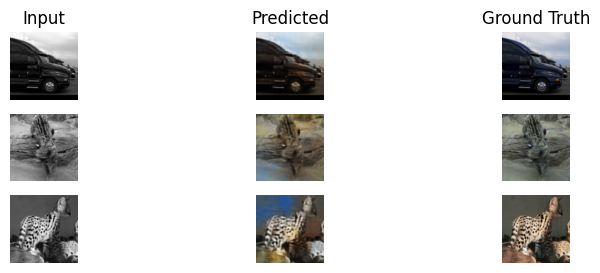

In [40]:
import matplotlib.pyplot as plt

for gray, rgb in test_ds.take(1):
    pred = autoencoder.predict(gray)

    plt.figure(figsize=(9,3))

    for i in range(3):
        plt.subplot(3,3,3*i+1)
        plt.imshow(gray[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.title("Input")

        plt.subplot(3,3,3*i+2)
        plt.imshow(pred[i])
        plt.axis("off")
        if i == 0: plt.title("Predicted")

        plt.subplot(3,3,3*i+3)
        plt.imshow(rgb[i])
        plt.axis("off")
        if i == 0: plt.title("Ground Truth")

    plt.show()
    break


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


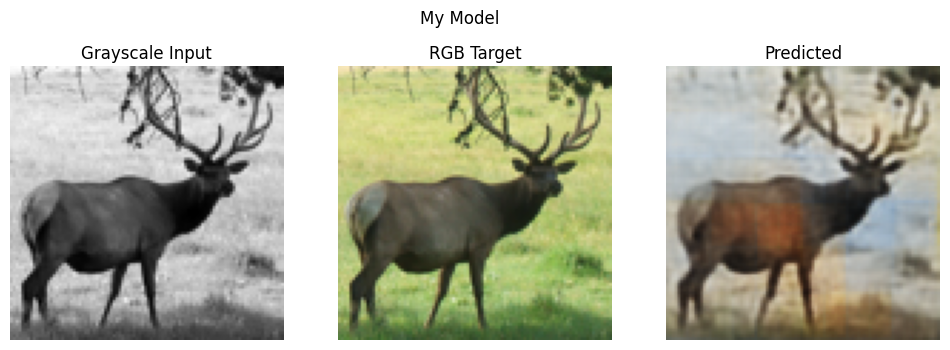

In [80]:
batch = next(iter(test_ds))
bw, rgb = batch
index = 10
img_bw, img_rgb = bw[index],rgb[index]
img_bw.shape, img_rgb.shape

y_pred = autoencoder.predict(img_bw[None, ...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(img_bw.numpy().squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("RGB Target")
plt.imshow(img_rgb.numpy())
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(y_pred)
plt.axis("off")
plt.suptitle("My Model")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


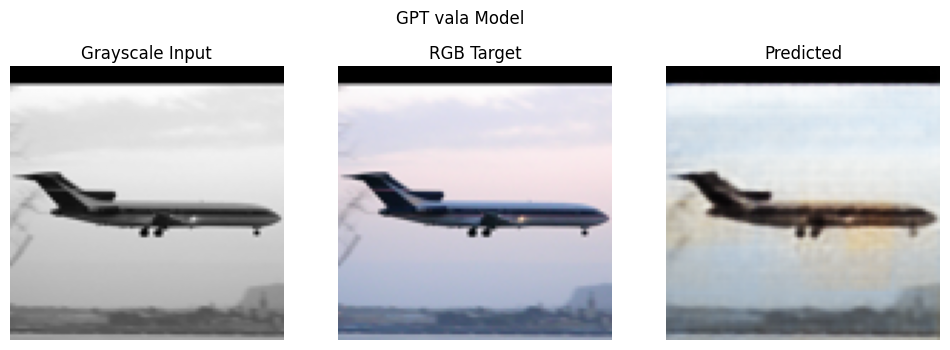

In [67]:
batch = next(iter(test_ds))
bw, rgb = batch
index = 17
img_bw, img_rgb = bw[index],rgb[index]
img_bw.shape, img_rgb.shape

y_pred = gpt_vala_model.predict(img_bw[None, ...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(img_bw.numpy().squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("RGB Target")
plt.imshow(img_rgb.numpy())
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(y_pred)
plt.axis("off")
plt.suptitle("GPT vala Model")

plt.show()

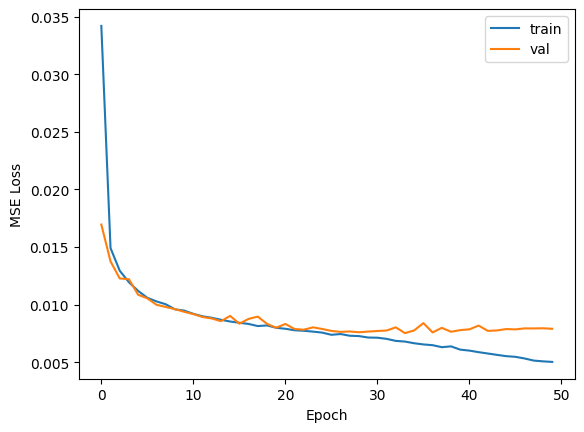

In [41]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.xlabel("Epoch")
plt.title("")
plt.ylabel("MSE Loss")
plt.show()


# Loss of Auto-Encoder

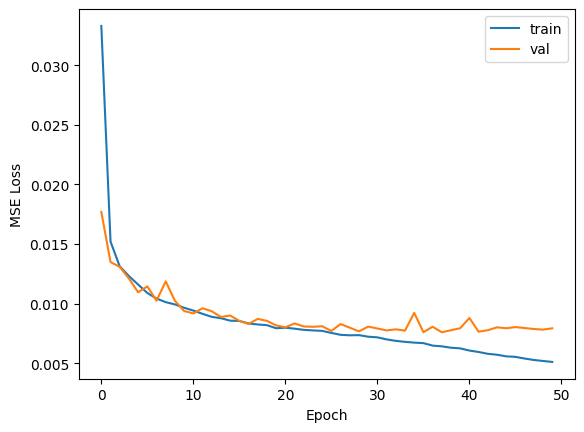

In [60]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# GPT Model loss

In [68]:
# saving the model
# autoencoder.save("bw_img_colorizer.keras")

# How to load model


```
from tensorflow.keras.models import load_model
model = load_model("bw_img_colorizer.keras")
```

now use model
```
y = model.predict(img_bw[None, ...])
```

